# 1. Dense / Full Attention 

'makine öğrenmesi harika bir alan' cümlesi için Attention Mekanizması Analizi
1. Adım: Kelime Gömme (Word Embeddings) - Boyut: 12
  'makine': [0.37 0.95 0.73 0.6  0.16 0.16 0.06 0.87 0.6  0.71 0.02 0.97]
  'öğrenmesi': [0.83 0.21 0.18 0.18 0.3  0.52 0.43 0.29 0.61 0.14 0.29 0.37]
  'harika': [0.46 0.79 0.2  0.51 0.59 0.05 0.61 0.17 0.07 0.95 0.97 0.81]
  'bir': [0.3  0.1  0.68 0.44 0.12 0.5  0.03 0.91 0.26 0.66 0.31 0.52]
  'alan': [0.55 0.18 0.97 0.78 0.94 0.89 0.6  0.92 0.09 0.2  0.05 0.33]
------------------------------------------------------------
2. Adım: Q, K, V Vektörlerinin Hesaplanması - Boyut: 4
Örnek olarak ilk kelimenin ('makine') Q, K, V vektörleri:
  Q_1: [3.22 3.26 2.57 3.28]
  K_1: [3.46 2.9  3.82 3.16]
  V_1: [2.72 3.22 2.81 3.18]
------------------------------------------------------------
3. Adım: Ham Dikkat Skorları (Q @ K.T)
Her satır bir 'sorgu' kelimesini, her sütun bir 'anahtar' kelimesini temsil eder.
[[40.77 22.64 35.45 28.23 38.83]
 [28.93 16.33 25.67 20.11 

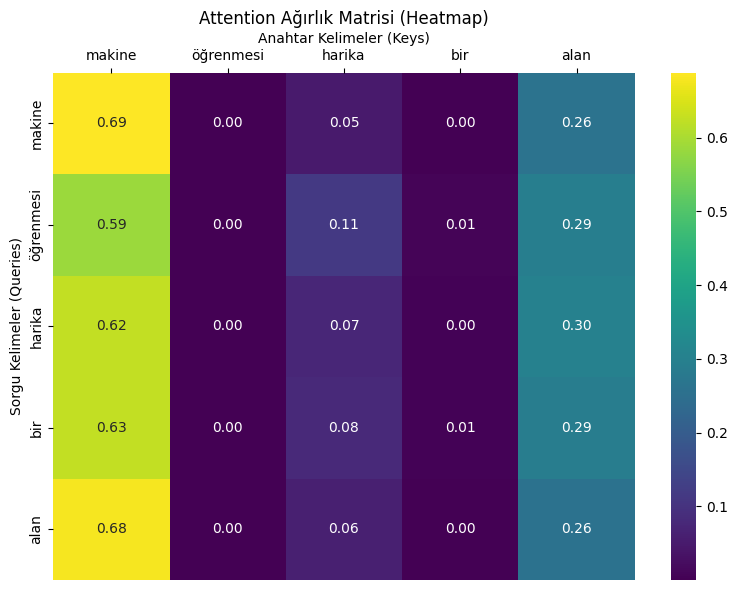

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def softmax(x):
    """Numerik olarak stabil bir softmax fonksiyonu."""
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

def visualize_attention(sentence, attention_matrix):
    """Attention matrisini bir ısı haritası olarak görselleştirir."""
    
    # Türkçe karakterleri destekleyen bir font bulma denemesi
    try:
        # Örnek olarak yaygın bir font veya sisteminizde olan bir fontu deneyin
        # Linux için: "DejaVu Sans", Windows için: "Arial", macOS için: "Helvetica Neue"
        font_prop = fm.FontProperties(fname='/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', size=12)
        plt.rcParams['font.family'] = font_prop.get_name()
    except:
        print("\nUyarı: Türkçe karakterler için 'DejaVu Sans' fontu bulunamadı. Etiketler düzgün görünmeyebilir.")
        print("Görselleştirmeyi iyileştirmek için sisteminizde var olan bir .ttf font dosyasının yolunu koda ekleyebilirsiniz.\n")


    tokens = sentence.split()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(attention_matrix, xticklabels=tokens, yticklabels=tokens, annot=True, fmt=".2f", cmap="viridis", ax=ax)
    
    ax.set_title("Attention Ağırlık Matrisi (Heatmap)")
    ax.set_xlabel("Anahtar Kelimeler (Keys)")
    ax.set_ylabel("Sorgu Kelimeler (Queries)")
    ax.xaxis.tick_top()  # X ekseni etiketlerini üste taşı
    ax.xaxis.set_label_position('top')
    
    plt.tight_layout()
    plt.show()

def attention_step_by_step(sentence):
    """
    Verilen bir cümle için attention mekanizmasını adım adım çalıştırır ve görselleştirir.
    """
    # makine öğrenmesi harika bir alan
    print(f"'{sentence}' cümlesi için Attention Mekanizması Analizi")
    print("=" * 60)

    tokens = sentence.split()
    vocab_size = len(tokens)
    
    # --- 1. Adım: Model Parametreleri ve Gömme Vektörleri ---
    # Eğitim kolaylığı için boyutları küçük tutuyoruz.
    d_model = 12  # Her kelimenin temsil edildiği vektör boyutu (Embedding boyutu)
    d_k = 4       # Query ve Key vektörlerinin boyutu (d_v de aynı olacak)
    
    # Her çalıştırmada aynı sonuçları almak için rastgelelik tohumu
    np.random.seed(42) 
    
    # Her kelime için rastgele bir gömme vektörü oluşturalım.
    # Gerçekte bu vektörler bir embedding katmanından gelir.
    embeddings = np.random.rand(vocab_size, d_model)
    
    print(f"1. Adım: Kelime Gömme (Word Embeddings) - Boyut: {d_model}")
    for i, token in enumerate(tokens):
        print(f"  '{token}': {np.round(embeddings[i], 2)}")
    print("-" * 60)
        
    # --- 2. Adım: Ağırlık Matrisleri ve Q, K, V Hesaplanması ---
    # Bu matrisler normalde modelin eğitim sırasında öğrendiği ağırlıklardır.
    # Biz burada rastgele ama sabit matrisler kullanacağız.
    W_q = np.random.rand(d_model, d_k)
    W_k = np.random.rand(d_model, d_k)
    W_v = np.random.rand(d_model, d_k) # d_v = d_k varsayalım
    
    # Her kelime için Q, K, V vektörlerini hesapla
    Q = embeddings @ W_q
    K = embeddings @ W_k
    V = embeddings @ W_v
    
    print(f"2. Adım: Q, K, V Vektörlerinin Hesaplanması - Boyut: {d_k}")
    print("Örnek olarak ilk kelimenin ('{}') Q, K, V vektörleri:".format(tokens[0]))
    print(f"  Q_1: {np.round(Q[0], 2)}")
    print(f"  K_1: {np.round(K[0], 2)}")
    print(f"  V_1: {np.round(V[0], 2)}")
    print("-" * 60)
    
    # --- 3. Adım: Ham Dikkat Skorları ---
    # Her sorgunun (Q) her anahtarla (K) ne kadar ilişkili olduğunu ölçeriz.
    # Formül: scores = Q * K^T
    scores = Q @ K.T
    
    print("3. Adım: Ham Dikkat Skorları (Q @ K.T)")
    print("Her satır bir 'sorgu' kelimesini, her sütun bir 'anahtar' kelimesini temsil eder.")
    print(np.round(scores, 2))
    print("-" * 60)
    
    # --- 4. Adım: Ölçekleme ---
    # Gradyanların çok küçülmesini engellemek için skorları ölçekleriz.
    # Formül: scores / sqrt(d_k)
    scaled_scores = scores / np.sqrt(d_k)
    
    print(f"4. Adım: Ölçeklenmiş Skorlar (Skorlar / sqrt({d_k}))")
    print(np.round(scaled_scores, 2))
    print("-" * 60)
    
    # --- 5. Adım: Softmax ---
    # Ölçeklenmiş skorları [0, 1] aralığında bir olasılık dağılımına dönüştürürüz.
    # Her satırın toplamı 1 olur. Bu bizim ATTENTION matrisimizdir.
    attention_weights = softmax(scaled_scores)
    
    print("5. Adım: Softmax ile Ağırlıkların Hesaplanması (Attention Matrisi)")
    print("Her kelimenin diğer kelimelere ne kadar 'dikkat' edeceğini gösterir.")
    print(np.round(attention_weights, 2))
    print("-" * 60)
    
    # --- 6. Adım: Sonuç Vektörlerinin Hesaplanması ---
    # Her kelime için nihai çıktı, dikkat ağırlıkları ile Değer (V) vektörlerinin
    # ağırlıklı toplamıdır.
    # Formül: output = attention_weights * V
    output = attention_weights @ V
    
    print("6. Adım: Nihai Çıktı Vektörleri (Attention_Weights @ V)")
    print("Her kelimenin yeni vektörü, cümlenin bağlam bilgisini içerir.")
    for i, token in enumerate(tokens):
        print(f"  '{token}' için yeni vektör: {np.round(output[i], 2)}")
    print("-" * 60)
    
    # --- 7. Adım: Görselleştirme ---
    print("7. Adım: Attention Matrisinin Görselleştirilmesi")
    visualize_attention(sentence, attention_weights)
    

if __name__ == '__main__':
    # Analiz edilecek örnek cümle
    ornek_cumle = "makine öğrenmesi harika bir alan"
    attention_step_by_step(ornek_cumle)